In [3]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

def evaluate_model(model, X, y, cv=5):
    """
    Evaluates a given model using cross-validation with specified metrics.

    Parameters:
    model: A machine learning model (e.g., RandomForestClassifier, SVC, etc.)
    X: Input feature data (numpy array or pandas DataFrame)
    y: Target labels (numpy array or pandas Series)
    cv: Number of cross-validation folds (default is 5)

    Returns:
    dict: Dictionary containing the mean values of accuracy, ROC-AUC, precision, recall, and F1-score across the cross-validation folds.
    """

    # Define the scoring metrics
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'roc_auc': make_scorer(roc_auc_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score)
    }

    # Perform cross-validation
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

    # Compute the mean of each metric across all folds
    results = {
        'accuracy': cv_results['test_accuracy'].mean(),
        'roc_auc': cv_results['test_roc_auc'].mean(),
        'precision': cv_results['test_precision'].mean(),
        'recall': cv_results['test_recall'].mean(),
        'f1': cv_results['test_f1'].mean()
    }

    return results




In [29]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_for_training.csv")

# Create the target column
coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']).columns

scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))
X = X_scaled_std.copy()  # Your scaled data
y = coffee_data['target']

In [30]:
# Assuming X and y are your input data and target, and model is your machine learning model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Call the function to evaluate the model
results = evaluate_model(rf_model, X_train, y_train, cv=5)

# Print the results
print("Cross-validation results (mean values):")
for metric, value in results.items():
    print(f"{metric.capitalize()}: {value:.4f}")

Cross-validation results (mean values):
Accuracy: 0.9348
Roc_auc: 0.9087
Precision: 0.9200
Recall: 0.8514
F1: 0.8810


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming X and y are your input data and target
# X_train, X_test, y_train, y_test already defined in your previous context

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Get predicted probabilities
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# Adjust the threshold for classification (e.g., 0.4 instead of 0.5)
threshold = 0.4
y_pred_adjusted = (y_pred_prob >= threshold).astype(int)

# Recalculate metrics with the adjusted threshold
print(f"Precision: {precision_score(y_test, y_pred_adjusted):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_adjusted):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_adjusted):.4f}")


Precision: 0.9429
Recall: 0.7174
F1-Score: 0.8148


In [32]:
# Adjust the threshold for classification again (e.g., 0.35)
threshold = 0.35
y_pred_adjusted = (y_pred_prob >= threshold).astype(int)

# Recalculate metrics with the new adjusted threshold
print(f"Precision: {precision_score(y_test, y_pred_adjusted):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_adjusted):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_adjusted):.4f}")


Precision: 0.9429
Recall: 0.7174
F1-Score: 0.8148


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Support Vector Classifier', SVC(probability=True, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Naive Bayes', GaussianNB())
]

# Loop through each model and apply the evaluation function
for name, model in models:
    print(f"Evaluating {name}...")
    results = evaluate_model(model, X_train, y_train, cv=5)
    
    # Print the results for each model
    print(f"Results for {name}:")
    for metric, value in results.items():
        print(f"{metric.capitalize()}: {value:.4f}")
    print("\n" + "-"*40 + "\n")

Evaluating Random Forest...
Results for Random Forest:
Accuracy: 0.9348
Roc_auc: 0.9087
Precision: 0.9200
Recall: 0.8514
F1: 0.8810

----------------------------------------

Evaluating Logistic Regression...
Results for Logistic Regression:
Accuracy: 0.9184
Roc_auc: 0.8856
Precision: 0.8910
Recall: 0.8124
F1: 0.8471

----------------------------------------

Evaluating Support Vector Classifier...
Results for Support Vector Classifier:
Accuracy: 0.9157
Roc_auc: 0.8775
Precision: 0.8947
Recall: 0.7924
F1: 0.8376

----------------------------------------

Evaluating K-Nearest Neighbors...
Results for K-Nearest Neighbors:
Accuracy: 0.8776
Roc_auc: 0.8476
Precision: 0.7758
Recall: 0.7814
F1: 0.7765

----------------------------------------

Evaluating Decision Tree...
Results for Decision Tree:
Accuracy: 0.9293
Roc_auc: 0.9047
Precision: 0.9031
Recall: 0.8510
F1: 0.8706

----------------------------------------

Evaluating Naive Bayes...
Results for Naive Bayes:
Accuracy: 0.5380
Roc_auc: 

In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_for_training.csv")

# Create the target column
coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']).columns

scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))
X = X_scaled_std.copy()  # Your scaled data
y = coffee_data['caffeine_percent']

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import numpy as np

from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import cross_validate
import numpy as np

def adjusted_r2(r2, n, p):
    """
    Calculate the Adjusted R² score.
    
    Parameters:
    r2: R² score
    n: Number of samples
    p: Number of features
    
    Returns:
    Adjusted R² score
    """
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

# Define a generalized evaluation function for regression models
def evaluate_regression_model(model, X, y, cv=5):
    """
    Evaluates a regression model using cross-validation with specified metrics.
    
    Parameters:
    model: A regression model (e.g., RandomForestRegressor, SVR, etc.)
    X: Input feature data (numpy array or pandas DataFrame)
    y: Target values (numpy array or pandas Series)
    cv: Number of cross-validation folds (default is 5)

    Returns:
    dict: Dictionary containing the mean values of MAE, MSE, RMSE, and R-squared across the cross-validation folds.
    """

        # Define the scoring metrics for regression
    scoring = {
        'mae': make_scorer(mean_absolute_error, greater_is_better=False),
        'mse': make_scorer(mean_squared_error, greater_is_better=False),
        'r2': make_scorer(r2_score),
        'explained_variance': make_scorer(explained_variance_score)
    }

    # Perform cross-validation
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_estimator=True)

    # Compute RMSE from MSE
    rmse_values = np.sqrt(-cv_results['test_mse'])

    # Compute Adjusted R² for each fold using the individual R² values, number of samples, and features
    n_samples = X.shape[0]
    n_features = X.shape[1]
    adjusted_r2_values = [adjusted_r2(r2, n_samples, n_features) for r2 in cv_results['test_r2']]

    # Compute the mean of each metric across all folds
    results = {
        'MAE': -cv_results['test_mae'].mean(),
        'MSE': -cv_results['test_mse'].mean(),
        'RMSE': rmse_values.mean(),
        'R2': cv_results['test_r2'].mean(),
        'Adjusted R2': np.mean(adjusted_r2_values),
        'Explained Variance': cv_results['test_explained_variance'].mean()
    }

    return results




In [36]:
# Define a list of regression models to evaluate
models = [
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Linear Regression', LinearRegression()),
    ('Support Vector Regressor', SVR()),
    ('K-Nearest Neighbors Regressor', KNeighborsRegressor()),
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42))
]

# Assuming X and y are your input data and target for regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Loop through each model and apply the evaluation function
for name, model in models:
    print(f"Evaluating {name}...")
    results = evaluate_regression_model(model, X_train, y_train, cv=5)
    
    # Print the results for each model
    print(f"Results for {name}:")
    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")
    print("\n" + "-"*40 + "\n")

Evaluating Random Forest Regressor...
Results for Random Forest Regressor:
MAE: 0.0099
MSE: 0.0028
RMSE: 0.0357
R2: -0.3528
Adjusted R2: -0.5466
Explained Variance: -0.2480

----------------------------------------

Evaluating Linear Regression...
Results for Linear Regression:
MAE: 0.0161
MSE: 0.0030
RMSE: 0.0391
R2: -0.8380
Adjusted R2: -1.1014
Explained Variance: -0.7249

----------------------------------------

Evaluating Support Vector Regressor...
Results for Support Vector Regressor:
MAE: 0.0589
MSE: 0.0063
RMSE: 0.0771
R2: -17.4505
Adjusted R2: -20.0945
Explained Variance: -1.2285

----------------------------------------

Evaluating K-Nearest Neighbors Regressor...
Results for K-Nearest Neighbors Regressor:
MAE: 0.0093
MSE: 0.0028
RMSE: 0.0314
R2: 0.3613
Adjusted R2: 0.2697
Explained Variance: 0.3766

----------------------------------------

Evaluating Decision Tree Regressor...
Results for Decision Tree Regressor:
MAE: 0.0083
MSE: 0.0028
RMSE: 0.0336
R2: 0.0960
Adjusted R2:

Best Performing is KNN - 

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Assuming X and y are your input data and target for regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the regression models to evaluate
models = [
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Linear Regression', LinearRegression()),
    ('Support Vector Regressor', SVR()),
    ('K-Nearest Neighbors Regressor', KNeighborsRegressor()),
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42)),
    ('GradientBoostingRegressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ('XGBRegressor', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
]

# Loop through each model and apply the evaluation function
for name, model in models:
    print(f"Evaluating {name}...")
    results = evaluate_regression_model(model, X_train, y_train, cv=5)
    
    # Print the results for each model
    print(f"Results for {name}:")
    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")
    print("\n" + "-"*40 + "\n")

Evaluating Random Forest Regressor...
Results for Random Forest Regressor:
MAE: 0.0099
MSE: 0.0028
RMSE: 0.0357
R2: -0.3528
Adjusted R2: -0.5466
Explained Variance: -0.2480

----------------------------------------

Evaluating Linear Regression...
Results for Linear Regression:
MAE: 0.0161
MSE: 0.0030
RMSE: 0.0391
R2: -0.8380
Adjusted R2: -1.1014
Explained Variance: -0.7249

----------------------------------------

Evaluating Support Vector Regressor...
Results for Support Vector Regressor:
MAE: 0.0589
MSE: 0.0063
RMSE: 0.0771
R2: -17.4505
Adjusted R2: -20.0945
Explained Variance: -1.2285

----------------------------------------

Evaluating K-Nearest Neighbors Regressor...
Results for K-Nearest Neighbors Regressor:
MAE: 0.0093
MSE: 0.0028
RMSE: 0.0314
R2: 0.3613
Adjusted R2: 0.2697
Explained Variance: 0.3766

----------------------------------------

Evaluating Decision Tree Regressor...
Results for Decision Tree Regressor:
MAE: 0.0083
MSE: 0.0028
RMSE: 0.0336
R2: 0.0960
Adjusted R2:

In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_for_training.csv")

# Create the target column
coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']).columns

# Scale the features
scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))

# Define X and y
y = coffee_data['target']
X = X_scaled_std

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_

# Use the stored column names to map the importances back to the feature names
important_features = sorted(zip(column_names, importances), key=lambda x: x[1], reverse=True)
feature_importance_dict = {feature: importance for feature, importance in zip(column_names, importances)}

# Display the most important features
for feature, importance in important_features:
    print(f"Feature: {feature}, Importance: {importance:.4f}")


Feature: clim_34_prec10_oct, Importance: 0.0730
Feature: env_75_geo_10, Importance: 0.0698
Feature: clim_25_prec1_jan, Importance: 0.0692
Feature: clim_14_tmax2_feb, Importance: 0.0643
Feature: clim_1_tmin1_jan, Importance: 0.0613
Feature: clim_27_prec3_mar, Importance: 0.0608
Feature: clim_40_temp_season, Importance: 0.0509
Feature: clim_26_prec2_feb, Importance: 0.0485
Feature: clim_69_cwd_annual, Importance: 0.0462
Feature: clim_28_prec4_apr, Importance: 0.0440
Feature: clim_35_prec11_nov, Importance: 0.0422
Feature: clim_13_tmax1_jan, Importance: 0.0401
Feature: env_73_asp, Importance: 0.0353
Feature: env_76_soi_10, Importance: 0.0349
Feature: env_74_solrad, Importance: 0.0327
Feature: clim_38_mean_diurn_range, Importance: 0.0321
Feature: clim_39_isotherm, Importance: 0.0268
Feature: env_78_wat_2, Importance: 0.0265
Feature: env_72_slo, Importance: 0.0244
Feature: env_79_forcov, Importance: 0.0186
Feature: env_76_soi_9, Importance: 0.0115
Feature: env_78_wat_10, Importance: 0.0080


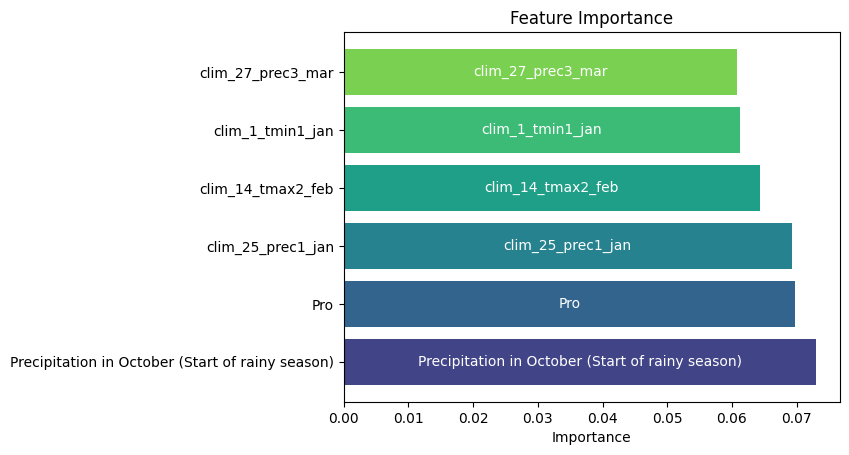

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'Precipitation in October (Start of rainy season)', 'Pro', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608]

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.barh(features, importances, color=colors)

# Add feature names inside the bars
for bar, feature in zip(bars, features):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height() / 2, 
            feature, ha='center', va='center', color='white', fontsize=10)

# Customize the chart
ax.set_xlabel('Importance')
ax.set_title('Feature Importance')

plt.show()


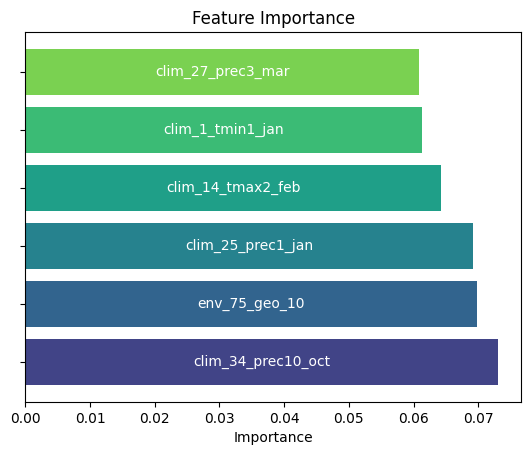

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608]

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.barh(features, importances, color=colors)

# Add feature names inside the bars
for bar, feature in zip(bars, features):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height() / 2, 
            feature, ha='center', va='center', color='white', fontsize=10)

# Customize the chart
ax.set_xlabel('Importance')
ax.set_title('Feature Importance')

# Hide the y-axis labels (feature names)
ax.set_yticklabels([])

# Show the plot
plt.show()


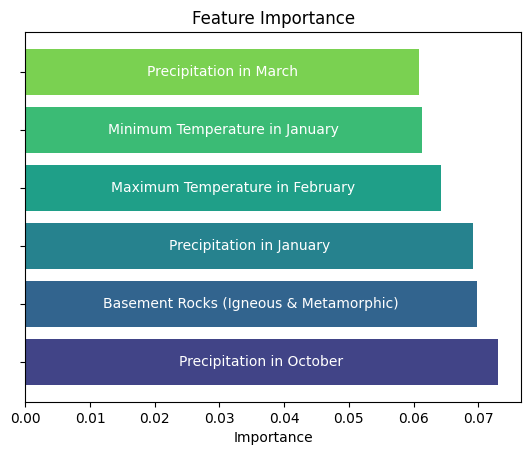

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608]

# Dictionary mapping feature codes to long names
feature_long_names = {
    'clim_34_prec10_oct': 'Precipitation in October',
    'env_75_geo_10': 'Basement Rocks (Igneous & Metamorphic)',
    'clim_25_prec1_jan': 'Precipitation in January',
    'clim_14_tmax2_feb': 'Maximum Temperature in February',
    'clim_1_tmin1_jan': 'Minimum Temperature in January',
    'clim_27_prec3_mar': 'Precipitation in March'
}

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.barh(features, importances, color=colors)

# Add long feature names inside the bars
for bar, feature in zip(bars, features):
    long_name = feature_long_names.get(feature, feature)  # Get the long name or fallback to the feature code
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height() / 2, 
            long_name, ha='center', va='center', color='white', fontsize=10)

# Customize the chart
ax.set_xlabel('Importance')
ax.set_title('Feature Importance')

# Hide the y-axis labels (feature names)
ax.set_yticklabels([])

# Show the plot
plt.show()


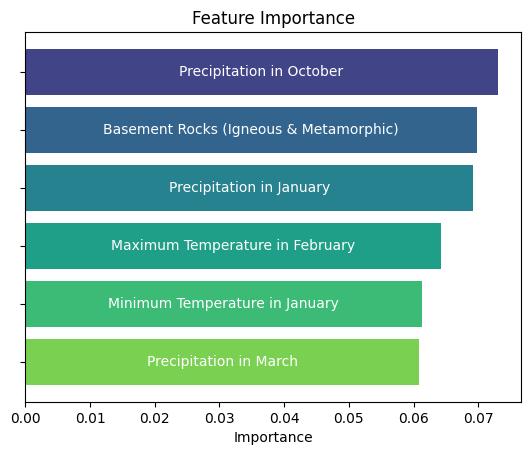

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608]

# Dictionary mapping feature codes to long names
feature_long_names = {
    'clim_34_prec10_oct': 'Precipitation in October',
    'env_75_geo_10': 'Basement Rocks (Igneous & Metamorphic)',
    'clim_25_prec1_jan': 'Precipitation in January',
    'clim_14_tmax2_feb': 'Maximum Temperature in February',
    'clim_1_tmin1_jan': 'Minimum Temperature in January',
    'clim_27_prec3_mar': 'Precipitation in March'
}

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.barh(features, importances, color=colors)

# Add long feature names inside the bars
for bar, feature in zip(bars, features):
    long_name = feature_long_names.get(feature, feature)  # Get the long name or fallback to the feature code
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height() / 2, 
            long_name, ha='center', va='center', color='white', fontsize=10)

# Invert the order of the y-axis to have the most important feature at the top
ax.invert_yaxis()

# Customize the chart
ax.set_xlabel('Importance')
ax.set_title('Feature Importance')

# Hide the y-axis labels (feature names)
ax.set_yticklabels([])

# Show the plot
plt.show()


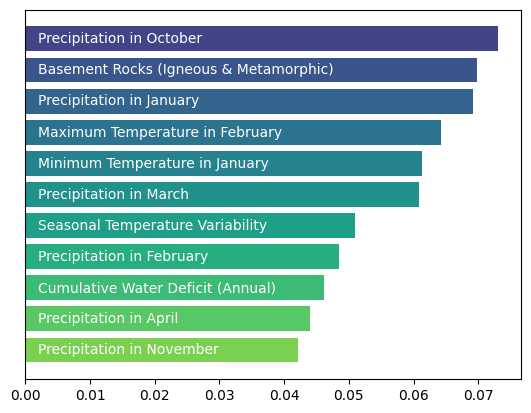

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar',
    'clim_40_temp_season', 'clim_26_prec2_feb', 'clim_69_cwd_annual',
    'clim_28_prec4_apr', 'clim_35_prec11_nov'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608, 0.0509, 0.0485, 0.0462, 0.0440, 0.0422]

# Dictionary mapping feature codes to long names
feature_long_names = {
    'clim_34_prec10_oct': 'Precipitation in October',
    'env_75_geo_10': 'Basement Rocks (Igneous & Metamorphic)',
    'clim_25_prec1_jan': 'Precipitation in January',
    'clim_14_tmax2_feb': 'Maximum Temperature in February',
    'clim_1_tmin1_jan': 'Minimum Temperature in January',
    'clim_27_prec3_mar': 'Precipitation in March',
    'clim_40_temp_season': 'Seasonal Temperature Variability',
    'clim_26_prec2_feb': 'Precipitation in February',
    'clim_69_cwd_annual': 'Cumulative Water Deficit (Annual)',
    'clim_28_prec4_apr': 'Precipitation in April',
    'clim_35_prec11_nov': 'Precipitation in November'
}

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.barh(features, importances, color=colors)

# Add long feature names inside the bars, left-aligned
for bar, feature in zip(bars, features):
    long_name = feature_long_names.get(feature, feature)  # Get the long name or fallback to the feature code
    width = bar.get_width()
    ax.text(0.002, bar.get_y() + bar.get_height() / 2,  # 0.02 to left-align the text within the bar
            long_name, ha='left', va='center', color='white', fontsize=10)

# Invert the order of the y-axis to have the most important feature at the top
ax.invert_yaxis()

# Customize the chart
#ax.set_xlabel('Importance')
#ax.set_title('Feature Importance')

# Hide the y-axis ticks and labels
ax.set_yticks([])  # Removes the ticks
ax.set_yticklabels([])  # Removes the labels on the y-axis

# Show the plot
plt.show()


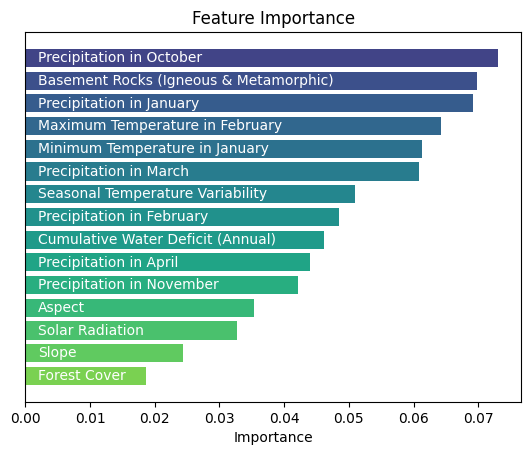

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar',
    'clim_40_temp_season', 'clim_26_prec2_feb', 'clim_69_cwd_annual',
    'clim_28_prec4_apr', 'clim_35_prec11_nov', 'env_74_solrad', 
    'env_72_slo', 'env_73_asp', 'env_79_forcov'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608, 0.0509, 0.0485, 0.0462, 0.0440, 0.0422, 0.0327, 0.0244, 0.0353, 0.0186]

# Dictionary mapping feature codes to long names
feature_long_names = {
    'clim_34_prec10_oct': 'Precipitation in October',
    'env_75_geo_10': 'Basement Rocks (Igneous & Metamorphic)',
    'clim_25_prec1_jan': 'Precipitation in January',
    'clim_14_tmax2_feb': 'Maximum Temperature in February',
    'clim_1_tmin1_jan': 'Minimum Temperature in January',
    'clim_27_prec3_mar': 'Precipitation in March',
    'clim_40_temp_season': 'Seasonal Temperature Variability',
    'clim_26_prec2_feb': 'Precipitation in February',
    'clim_69_cwd_annual': 'Cumulative Water Deficit (Annual)',
    'clim_28_prec4_apr': 'Precipitation in April',
    'clim_35_prec11_nov': 'Precipitation in November',
    'env_74_solrad': 'Solar Radiation',
    'env_72_slo': 'Slope',
    'env_73_asp': 'Aspect',
    'env_79_forcov': 'Forest Cover'
}

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart
fig, ax = plt.subplots()
bars = ax.barh(features, importances, color=colors)

# Add long feature names inside the bars, left-aligned
for bar, feature in zip(bars, features):
    long_name = feature_long_names.get(feature, feature)  # Get the long name or fallback to the feature code
    width = bar.get_width()
    ax.text(0.002, bar.get_y() + bar.get_height() / 2, 
            long_name, ha='left', va='center', color='white', fontsize=10)

# Invert the order of the y-axis to have the most important feature at the top
ax.invert_yaxis()

# Customize the chart
#ax.set_xlabel('Importance')
#ax.set_title('Feature Importance')

# Hide the y-axis ticks and labels
ax.set_yticks([])  # Removes the ticks
ax.set_yticklabels([])  # Removes the labels on the y-axis

# Show the plot
plt.show()


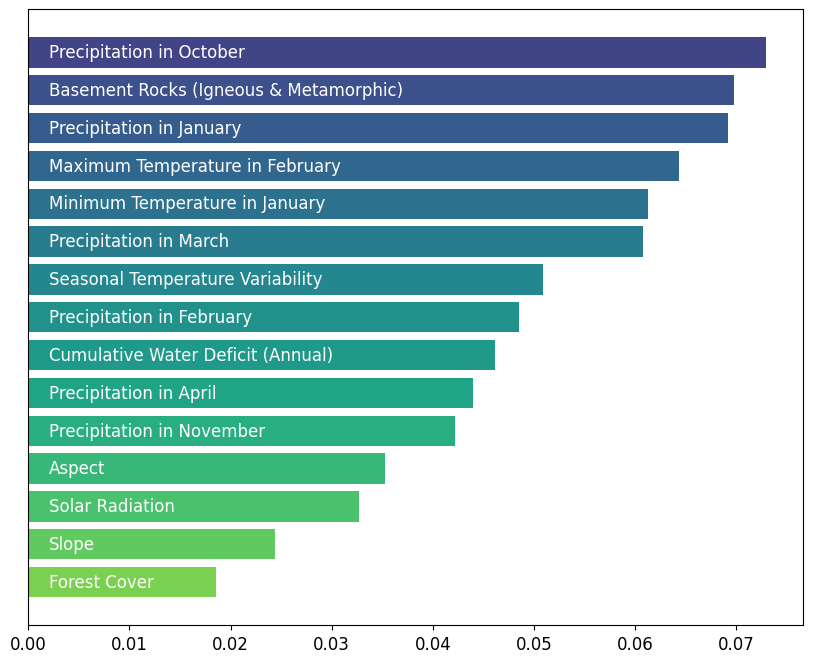

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar',
    'clim_40_temp_season', 'clim_26_prec2_feb', 'clim_69_cwd_annual',
    'clim_28_prec4_apr', 'clim_35_prec11_nov', 'env_74_solrad', 
    'env_72_slo', 'env_73_asp', 'env_79_forcov'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608, 0.0509, 0.0485, 0.0462, 0.0440, 0.0422, 0.0327, 0.0244, 0.0353, 0.0186]

# Dictionary mapping feature codes to long names
feature_long_names = {
    'clim_34_prec10_oct': 'Precipitation in October',
    'env_75_geo_10': 'Basement Rocks (Igneous & Metamorphic)',
    'clim_25_prec1_jan': 'Precipitation in January',
    'clim_14_tmax2_feb': 'Maximum Temperature in February',
    'clim_1_tmin1_jan': 'Minimum Temperature in January',
    'clim_27_prec3_mar': 'Precipitation in March',
    'clim_40_temp_season': 'Seasonal Temperature Variability',
    'clim_26_prec2_feb': 'Precipitation in February',
    'clim_69_cwd_annual': 'Cumulative Water Deficit (Annual)',
    'clim_28_prec4_apr': 'Precipitation in April',
    'clim_35_prec11_nov': 'Precipitation in November',
    'env_74_solrad': 'Solar Radiation',
    'env_72_slo': 'Slope',
    'env_73_asp': 'Aspect',
    'env_79_forcov': 'Forest Cover'
}

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart with a larger figure size
fig, ax = plt.subplots(figsize=(10, 8))  # Increase figure size (width, height)
bars = ax.barh(features, importances, color=colors)

# Add long feature names inside the bars, left-aligned, with larger font
for bar, feature in zip(bars, features):
    long_name = feature_long_names.get(feature, feature)  # Get the long name or fallback to the feature code
    width = bar.get_width()
    ax.text(0.002, bar.get_y() + bar.get_height() / 2, 
            long_name, ha='left', va='center', color='white', fontsize=12)  # Larger font size

# Invert the order of the y-axis to have the most important feature at the top
ax.invert_yaxis()

# Customize the chart: larger labels and title
#ax.set_xlabel('Importance', fontsize=14)  # Larger font for the x-axis label
#ax.set_title('Feature Importance', fontsize=16)  # Larger font for the title

# Hide the y-axis ticks and labels
ax.set_yticks([])  # Removes the ticks
ax.set_yticklabels([])  # Removes the labels on the y-axis

# Increase the size of the tick labels on the x-axis
ax.tick_params(axis='x', labelsize=12)

# Show the plot
plt.show()


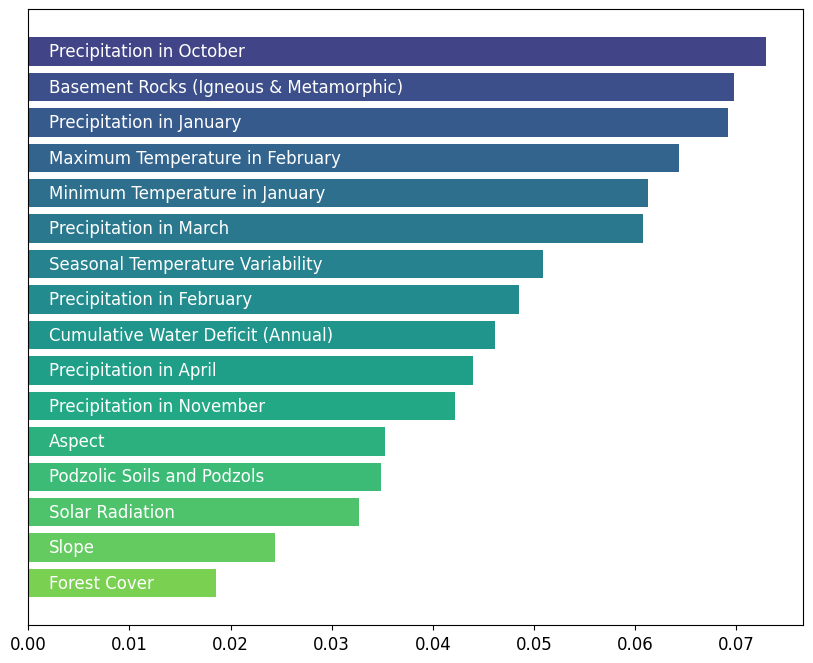

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
features = [
    'clim_34_prec10_oct', 'env_75_geo_10', 'clim_25_prec1_jan', 
    'clim_14_tmax2_feb', 'clim_1_tmin1_jan', 'clim_27_prec3_mar',
    'clim_40_temp_season', 'clim_26_prec2_feb', 'clim_69_cwd_annual',
    'clim_28_prec4_apr', 'clim_35_prec11_nov', 'env_74_solrad', 
    'env_72_slo', 'env_73_asp', 'env_79_forcov', 'env_76_soi_10'
]
importances = [0.0730, 0.0698, 0.0692, 0.0643, 0.0613, 0.0608, 0.0509, 0.0485, 0.0462, 0.0440, 0.0422, 0.0327, 0.0244, 0.0353, 0.0186, 0.0349]

# Dictionary mapping feature codes to long names
feature_long_names = {
    'clim_34_prec10_oct': 'Precipitation in October',
    'env_75_geo_10': 'Basement Rocks (Igneous & Metamorphic)',
    'clim_25_prec1_jan': 'Precipitation in January',
    'clim_14_tmax2_feb': 'Maximum Temperature in February',
    'clim_1_tmin1_jan': 'Minimum Temperature in January',
    'clim_27_prec3_mar': 'Precipitation in March',
    'clim_40_temp_season': 'Seasonal Temperature Variability',
    'clim_26_prec2_feb': 'Precipitation in February',
    'clim_69_cwd_annual': 'Cumulative Water Deficit (Annual)',
    'clim_28_prec4_apr': 'Precipitation in April',
    'clim_35_prec11_nov': 'Precipitation in November',
    'env_74_solrad': 'Solar Radiation',
    'env_72_slo': 'Slope',
    'env_73_asp': 'Aspect',
    'env_79_forcov': 'Forest Cover',
    'env_76_soi_10': 'Podzolic Soils and Podzols'
}

# Sort features and importances from most to least important
sorted_data = sorted(zip(importances, features), reverse=True)
importances, features = zip(*sorted_data)

# Define colors for each bar
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(features)))

# Create the bar chart with a larger figure size
fig, ax = plt.subplots(figsize=(10, 8))  # Increase figure size (width, height)
bars = ax.barh(features, importances, color=colors)

# Add long feature names inside the bars, left-aligned, with larger font
for bar, feature in zip(bars, features):
    long_name = feature_long_names.get(feature, feature)  # Get the long name or fallback to the feature code
    width = bar.get_width()
    ax.text(0.002, bar.get_y() + bar.get_height() / 2, 
            long_name, ha='left', va='center', color='white', fontsize=12)  # Larger font size

# Invert the order of the y-axis to have the most important feature at the top
ax.invert_yaxis()

# Customize the chart: larger labels and title
#ax.set_xlabel('Importance', fontsize=14)  # Larger font for the x-axis label
#ax.set_title('Feature Importance', fontsize=16)  # Larger font for the title

# Hide the y-axis ticks and labels
ax.set_yticks([])  # Removes the ticks
ax.set_yticklabels([])  # Removes the labels on the y-axis

# Increase the size of the tick labels on the x-axis
ax.tick_params(axis='x', labelsize=12)

# Show the plot
plt.show()
